# Evaluating the Impact of Marketing Campaigns

In a fast paced world like we experience daily, every company seeks one means of the other to maintain profitability and gain quantifiable market share. For marketing companies they focus on consistently running successful campaigns in a complex and competitive market. 

For this to be possible, they set up on A/B testing systems, a randomized experimentation method that involves presenting different versions of a variable (such as a web page, banner, or ad) to separate segments of the audience simultaneously. This approach helps determine which version has the most significant impact on business metrics.

To address these questions, the company conducted an A/B test, where the majority of participants were exposed to ads (the experimental group) and a smaller portion saw a Public Service Announcement (PSA) or nothing (the control group).

## About the Dataset

| **Feature**         | **Description**                                                                                 |
|--------------------|-------------------------------------------------------------------------------------------------|
| **Row Index**      | Row index                                                                                      |
| **User ID**        | Unique identifier for each user                                                                |
| **Test Group**     | Indicates whether the user was in the "ad" group (saw the advertisement) or the "psa" group (saw the public service announcement or nothing) |
| **Converted**      | Indicates whether the user bought the product (True) or not (False)                            |
| **Total Ads**      | The number of ads seen by the user                                                             |
| **Most Ads Day**   | The day when the user saw the highest number of ads                                            |
| **Most Ads Hour**  | The hour of the day when the user saw the highest number of ads                                |

The marketing data can be found **[here](https://drive.google.com/file/d/1YDS_6_1sCJPjucNX6Feo9uGa8B3w8Xzk/view?usp=sharing)**.

## Objective

The primary objective of this case study is to perform hypothesis testing on the e-commerce dataset to compare different groups or features. Specifically, we aim to:

- Analyze the experimental and control groups to determine if the ads were successful.

- Estimate the potential revenue generated from the ads.

- Assess the statistical significance of the differences between the groups using A/B testing techniques.

### Importaion of the necessary modules
This includes importing all the models needed for this analysis

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
market_df = pd.read_csv(r'C:\Users\pc\Downloads\marketing_AB.csv')
market_df

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14
...,...,...,...,...,...,...,...
588096,588096,1278437,ad,False,1,Tuesday,23
588097,588097,1327975,ad,False,1,Tuesday,23
588098,588098,1038442,ad,False,3,Tuesday,23
588099,588099,1496395,ad,False,1,Tuesday,23


### Data Cleaning
Delving into the data to get rid of inconsistency and making it pretty and more acceptable for use

In [56]:
market_df.duplicated().sum()

0

In [57]:
market_df.isna().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [58]:
market_df.drop(columns = ['Unnamed: 0','user id'], inplace=True)

In [59]:
market_df

,test group,converted,total ads,most ads day,most ads hour
0,ad,False,130,Monday,20
1,ad,False,93,Tuesday,22
2,ad,False,21,Tuesday,18
3,ad,False,355,Tuesday,10
4,ad,False,276,Friday,14
...,...,...,...,...,...
588096,ad,False,1,Tuesday,23
588097,ad,False,1,Tuesday,23
588098,ad,False,3,Tuesday,23
588099,ad,False,1,Tuesday,23


In [60]:
# # Separate the experimenta group from the control group
exp = market_df[market_df['test group'] == 'ad']
con = market_df[market_df['test group'] == 'psa']

Text(0.5, 1.0, 'Views Count')

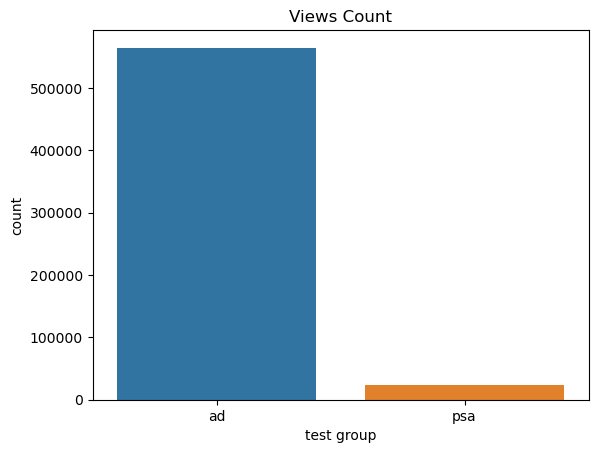

In [61]:
# How many Ads were watched as opposed to the psa
sns.countplot(data= market_df, x='test group')
plt.title('Views Count')

Text(0.5, 1.0, 'Sales Count')

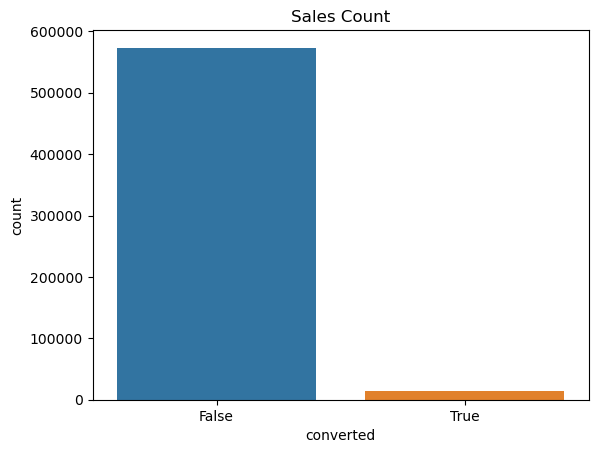

In [62]:
#How many user bought the product
sns.countplot(data= market_df, x='converted')
plt.title('Sales Count')

Text(0.5, 1.0, 'Comparison Between Experimental And Control Group')

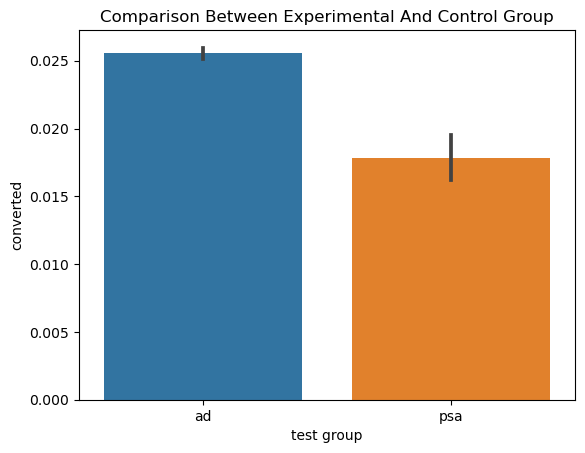

In [63]:
# Compare the experimental and control groups in terms of sales
sns.barplot(data= market_df, x= 'test group', y= 'converted')
plt.title('Comparison Between Experimental And Control Group')

In [64]:
sales= pd.crosstab(market_df['test group'], market_df['converted'], normalize='index')
sales

converted,False,True
test group,,
ad,0.974453,0.025547
psa,0.982146,0.017854


The plot above indicates that the people who saw the ads bought more products than those who didn't

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'Monday'),
  Text(1, 0, 'Tuesday'),
  Text(2, 0, 'Friday'),
  Text(3, 0, 'Saturday'),
  Text(4, 0, 'Wednesday'),
  Text(5, 0, 'Sunday'),
  Text(6, 0, 'Thursday')])

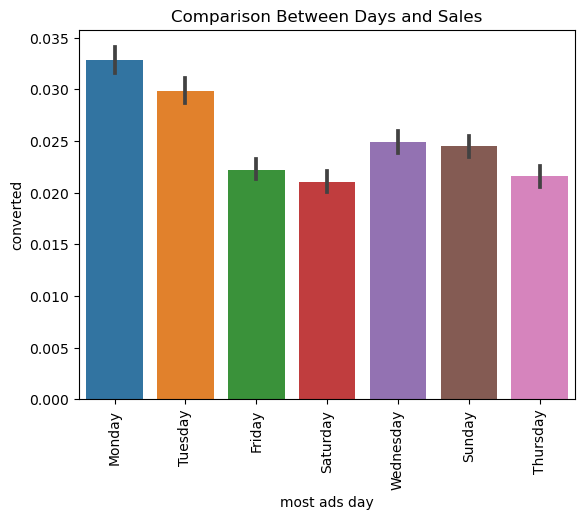

In [65]:
# Wat days had more sales
sns.barplot(data= market_df, x= 'most ads day', y= 'converted')
plt.title('Comparison Between Days and Sales')
plt.xticks(rotation=90)

In [66]:
pd.crosstab(market_df['most ads day'], market_df['converted'], normalize='index')

converted,False,True
most ads day,,
Friday,0.977788,0.022212
Monday,0.967188,0.032812
Saturday,0.978949,0.021051
Sunday,0.975524,0.024476
Thursday,0.978429,0.021571
Tuesday,0.970160,0.029840
Wednesday,0.975058,0.024942


The plot above shows the days people bought the most products based on ads

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'Monday'),
  Text(1, 0, 'Tuesday'),
  Text(2, 0, 'Friday'),
  Text(3, 0, 'Saturday'),
  Text(4, 0, 'Wednesday'),
  Text(5, 0, 'Sunday'),
  Text(6, 0, 'Thursday')])

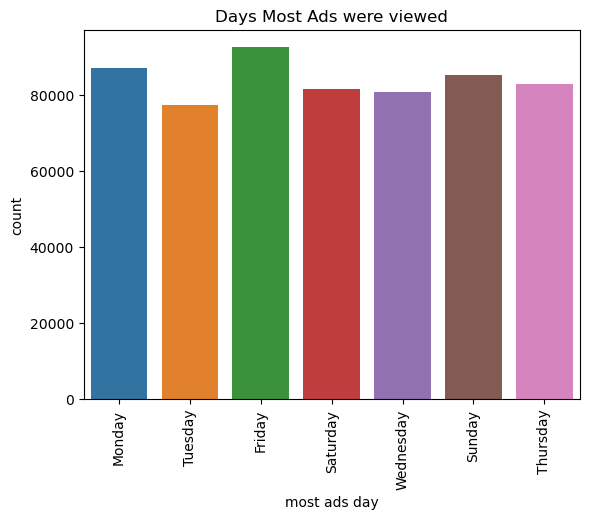

In [67]:
# What days were most Ads watched
sns.countplot(data= market_df, x='most ads day')
plt.title('Days Most Ads were viewed')
plt.xticks(rotation = 90)

Text(0.5, 1.0, 'Hours Spent Watching The Ads Per Day')

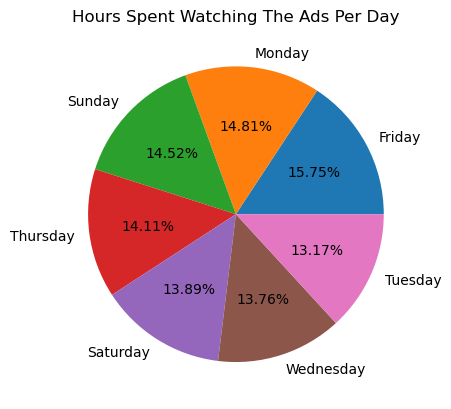

In [68]:
# How much time was spent watching the ads each day
plt.pie(market_df['most ads day'].value_counts(), labels= market_df['most ads day'].value_counts().index, autopct='%0.2f%%')
plt.title('Hours Spent Watching The Ads Per Day')

The highest ads view was on a Friday and this can be because people are just staartin

Text(0.5, 1.0, 'Time most Ads were viewed')

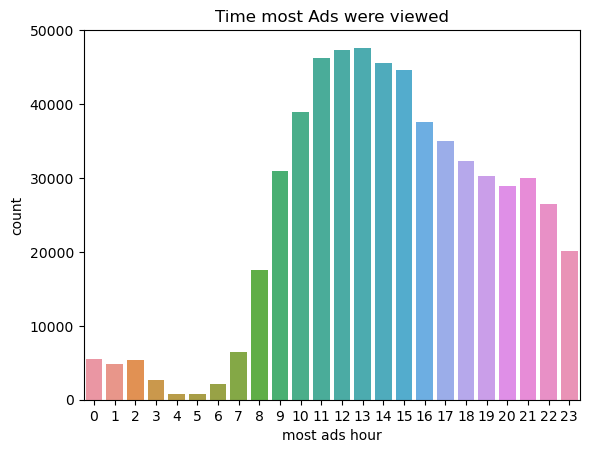

In [69]:
#What hour of the day are most Ads watched
sns.countplot(data= market_df, x='most ads hour')
plt.title('Time most Ads were viewed')

Text(0.5, 1.0, ' Sales Trend Over The Week')

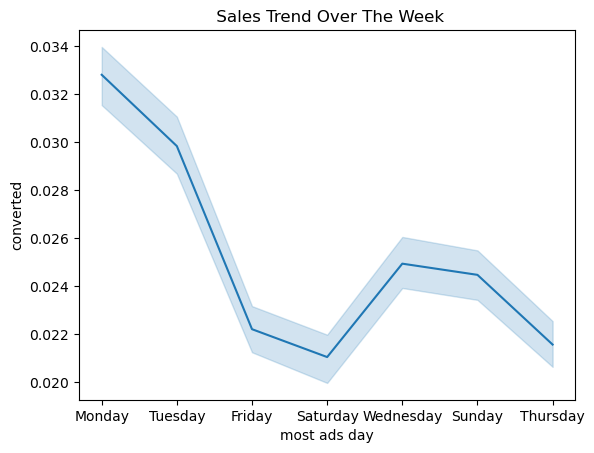

In [70]:
# Sales trends over the week
sns.lineplot(data= market_df, x= 'most ads day', y = 'converted')
plt.title(' Sales Trend Over The Week')

Text(0.5, 1.0, ' Sales Trend Over The Week ')

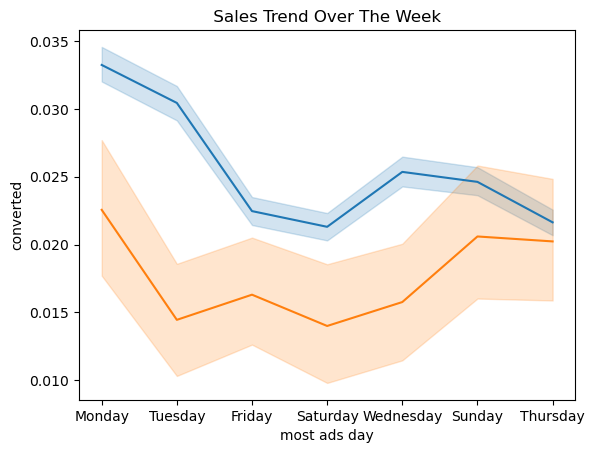

In [74]:
# Sales trends over the week with ads and psa
sns.lineplot(data= exp, x= 'most ads day', y = 'converted')
sns.lineplot(data= con, x= 'most ads day', y = 'converted')
plt.title(' Sales Trend Over The Week ')

In [72]:
from scipy.stats import chi2_contingency
alpha = 0.05

In [73]:
for variable in market_df.columns:
    if variable != 'converted':
        con_table = pd.crosstab(market_df[variable], market_df['converted'], normalize='index')
        chi2, p, _,_ = chi2_contingency(con_table)
        print(f"\nChi-squared test for {variable} vs. converted")
        print(f"Chi-squared value: {chi2}")
        print(f"p-value: {p}")
        if p < alpha:
            print(f' The difference in sales across {variable} is statistically significant')
        else:
            print(f' The difference in sales across {variable} is not statistically significant')


Chi-squared test for test group vs. converted
Chi-squared value: 0.0
p-value: 1.0
 The difference in sales across test group is not statistically significant

Chi-squared test for total ads vs. converted
Chi-squared value: 291.1393837537304
p-value: 1.0
 The difference in sales across total ads is not statistically significant

Chi-squared test for most ads day vs. converted
Chi-squared value: 0.004844646719192529
p-value: 0.9999999976354084
 The difference in sales across most ads day is not statistically significant

Chi-squared test for most ads hour vs. converted
Chi-squared value: 0.042124201165154265
p-value: 1.0
 The difference in sales across most ads hour is not statistically significant


From the test done above, there is no difference in users' purchasing when they see an ad, a public service announcement, or nothing. The purchasing rate is still about the same.